# Cartographie thermique — Notebook FINAL : ExtraTrees + IDW causal

Notebook final tiré de la V3 (`NOTEBOOK_THERMIQUE_ExtraTrees_GaussianProcess_V3`). **Aucune recherche ici** : ni tuning, ni ablation, ni comparatif de modèles, ni multi-seeds. On rejoue le prétraitement V3 à l'identique (même lecture/nettoyage, mêmes régimes, mêmes features, même `idw_causal`), on charge les modèles retenus et on produit les cartes.

**Modèles retenus (un par régime)** — `prédiction = idw_causal + résidu prédit par ExtraTrees`

| Régime | Modèle | `n_estimators` | `max_depth` | `min_samples_leaf` |
|---|---|---|---|---|
| Stationnaire | ExtraTrees (résidu) + IDW causal | 500 | 10 | 4 |
| Instationnaire | ExtraTrees (résidu) + IDW causal | 300 | 20 | 2 |

Le modèle tuné instationnaire `100/20/1` n'est **pas** utilisé (moins performant sur le test final).

**Chargement** : les modèles sont chargés avec `joblib` s'ils existent dans `modeles_sauvegardes/` (et si leurs hyperparamètres et leurs features correspondent) ; sinon ils sont réentraînés une seule fois, avec le protocole de la section 14bis de la V3, puis sauvegardés.

**Deux types de chiffres, clairement séparés**
- **Généralisation** (test final V3, méthodologie anti-leakage inchangée : positions tenues à l'écart en stationnaire, derniers 20 % chronologiques par séquence en instationnaire). Les modèles sauvegardés ayant été entraînés sur *tous* les points, ces chiffres viennent d'un modèle « hold-out » avec les mêmes hyperparamètres, entraîné sur le train uniquement (mis en cache dans `modeles_sauvegardes/`).
- **Ajustement pleine grille** (modèle final sur tous les points, comme en 14bis) : sert à remplir les cartes, ne mesure pas une généralisation.

In [1]:
# === 1 — Imports et configuration ===
import os, re, zlib, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm, colors
from mpl_toolkits.mplot3d import Axes3D  # noqa (projection='3d')
from scipy import stats
from scipy.interpolate import griddata, RectBivariateSpline
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 11})

# --- Paramètres physiques de la grille (identiques à la V3, section 1) ---
LARGEUR  = 8   # axe X : A–H  (0–7) — 8 poteaux/colonnes
LONGUEUR = 5   # axe Y : 0–4        — 5 rangées en profondeur
HAUTEUR  = 3   # niveaux H1–H3 (axe Z : 0–2) — 3 hauteurs de capteur par poteau
N_CAPTEURS = 120

T_MIN_PHYSIQUE = -50
T_MAX_PHYSIQUE = 200

ESPACEMENT_X = 1.1   # entre deux poteaux successifs (m)
ESPACEMENT_Y = 1.2   # entre deux rangées successives (m)
ESPACEMENT_Z = 0.5   # unité de base verticale (m)
ALTITUDES_Z = [0.5, 1.0, 1.5]   # z=0 -> 0.5 m, z=1 -> 1.0 m, z=2 -> 1.5 m

LARGEUR_M  = (LARGEUR  - 1) * ESPACEMENT_X
LONGUEUR_M = (LONGUEUR - 1) * ESPACEMENT_Y
HAUTEUR_M  = ALTITUDES_Z[-1]
PAS_TEMPOREL_SEQ = 20.0  # secondes

# --- Modèles retenus (résultat de la recherche menée dans la V3 : aucune recherche ici) ---
DOSSIER_MODELES = 'modeles_sauvegardes'
RANDOM_STATE = 42
MODELES_RETENUS = {
    'stationnaire': dict(
        params=dict(n_estimators=500, max_depth=10, min_samples_leaf=4),
        # 1er fichier = fichier du notebook FINAL ; suivant = sortie du tuning V3 (section 19bis)
        candidats=['extratrees_idw_final_stationnaire.joblib', 'extratrees_idw_tuned_stationnaire.joblib']),
    'instationnaire': dict(
        params=dict(n_estimators=300, max_depth=20, min_samples_leaf=2),
        # 300/20/2 = modèle de la section 14bis/20 de la V3.
        # extratrees_idw_tuned_instationnaire.joblib (100/20/1) est volontairement IGNORÉ.
        candidats=['extratrees_idw_final_instationnaire.joblib', 'extratrees_idw_instationnaire.joblib']),
}
REGIMES = ['stationnaire', 'instationnaire']

print(f'Grille : {LARGEUR} × {LONGUEUR} × {HAUTEUR} ({LARGEUR_M:.1f} m × {LONGUEUR_M:.1f} m, '
      f'jusqu\'à {HAUTEUR_M:.1f} m) — {N_CAPTEURS} capteurs')
for r, cfg in MODELES_RETENUS.items():
    print(f"Modèle retenu {r:15s}: ExtraTrees résidu + IDW causal, {cfg['params']}")

Grille : 8 × 5 × 3 (7.7 m × 4.8 m, jusqu'à 1.5 m) — 120 capteurs
Modèle retenu stationnaire   : ExtraTrees résidu + IDW causal, {'n_estimators': 500, 'max_depth': 10, 'min_samples_leaf': 4}
Modèle retenu instationnaire : ExtraTrees résidu + IDW causal, {'n_estimators': 300, 'max_depth': 20, 'min_samples_leaf': 2}


In [2]:
# === 2 — Chargement du dataset principal (lecture + nettoyage, identiques à la V3) ===
def lire_et_nettoyer_csv(filename, n_capteurs=N_CAPTEURS,
                          t_min_phys=T_MIN_PHYSIQUE, t_max_phys=T_MAX_PHYSIQUE,
                          pas_temporel_secours=PAS_TEMPOREL_SEQ):
    """Lit un CSV brut (export type Row, Time, Temperature1..N) et retourne
    un DataFrame propre avec colonnes temp_cols, 't_sec', 'direction_encode'."""
    df_raw = None
    for sep, dec in [(',', ','), (';', '.'), (',', '.'), (';', ',')]:
        try:
            tmp = pd.read_csv(filename, sep=sep, decimal=dec, dtype=str)
            if tmp.shape[1] > 10:
                df_raw = tmp
                break
        except Exception:
            pass
    if df_raw is None:
        raise ValueError(f'Impossible de lire {filename} — vérifiez le format.')

    # Detection robuste des lignes corrompues : la colonne 'Row' (1ere colonne)
    # doit etre un entier valide. Certains exports CSV perdent ce numero sur la
    # toute premiere ligne de donnees, ce qui decale TOUTES les valeurs d'une
    # colonne vers la gauche (un fragment de timestamp tronque atterrit dans
    # 'Row', une temperature atterrit dans 'Time', etc. -- vu sur ThermoCouple.csv,
    # ligne 2 : ':59.296,29.8556,...' au lieu de '1,7:52:59 AM,29.8556,...').
    # L'ancienne detection par regex sur le contenu du champ ne couvrait pas ce
    # cas (commence par ':', pas par un chiffre) -- on verifie directement la
    # validite du numero de ligne, plus robuste que deviner le format casse.
    row_col = df_raw.columns[0]
    row_num = pd.to_numeric(df_raw[row_col], errors='coerce')
    n_avant_corrompu = len(df_raw)
    df_raw = df_raw[row_num.notna()].reset_index(drop=True)
    n_supprimees = n_avant_corrompu - len(df_raw)
    if n_supprimees > 0:
        print(f"  [{filename}] {n_supprimees} ligne(s) corrompue(s) "
              f"(numero de ligne invalide -> colonnes decalees) supprimee(s).")

    df = df_raw.copy()
    temp_cols_all = [c for c in df.columns
                     if re.match(r'Temperature\d+', c, re.I) or re.match(r'Temp\d+', c, re.I)]
    temp_cols = temp_cols_all[:n_capteurs]

    for col in temp_cols:
        df[col] = (df[col].astype(str).str.replace(',', '.', regex=False)
                   .pipe(pd.to_numeric, errors='coerce'))

    time_col = df.columns[1]

    for col in temp_cols:
        mask = (df[col] < t_min_phys) | (df[col] > t_max_phys)
        df.loc[mask, col] = np.nan
    for col in temp_cols:
        p1, p99 = df[col].quantile([0.01, 0.99])
        df[col] = df[col].clip(p1, p99)

    # Parsing du temps
    time_ok = False
    for fmt in ['%I:%M:%S %p', '%H:%M:%S', '%M:%S', '%H:%M:%S.%f', '%H:%M']:
        try:
            parsed = pd.to_datetime(df[time_col].astype(str).str.strip(), format=fmt, errors='coerce')
            if parsed.notna().sum() >= max(1, len(df) * 0.5):
                df['time'] = parsed
                t0 = df['time'].min()
                df['t_sec'] = (df['time'] - t0).dt.total_seconds()
                time_ok = True
                break
        except Exception:
            pass
    if not time_ok:
        df['t_sec'] = np.arange(len(df)) * pas_temporel_secours

    # Direction aller/retour
    if 'Direction' in df.columns or 'direction' in df.columns:
        dir_col = 'Direction' if 'Direction' in df.columns else 'direction'
        df['direction'] = df[dir_col].astype(str).str.upper()
    else:
        df['t_diff']    = df['t_sec'].diff()
        df['is_jump']   = df['t_diff'] < 0
        df['cycle_num'] = df['is_jump'].cumsum()
        df['direction'] = df['cycle_num'].apply(lambda x: 'ALLER' if x % 2 == 0 else 'RETOUR')
    df['direction_encode'] = (df['direction'] == 'RETOUR').astype(int)
    if df['direction_encode'].nunique() <= 1:
        print(f"  [{filename}] attention : 'direction_encode' est constante sur ce fichier "
              f"(pas de colonne Direction dans le CSV, et aucun retour en arriere detecte "
              f"dans t_sec -> une seule session continue) -- cette feature n'apporte aucune "
              f"information sur ce fichier.")

    df['temperature_mean'] = df[temp_cols].mean(axis=1)

    return df, temp_cols

print('Fonction lire_et_nettoyer_csv() prête.')


try:
    from google.colab import files
    print('Sélectionnez votre fichier CSV principal (mesure de référence)...')
    uploaded = files.upload()
    FICHIER_PRINCIPAL = list(uploaded.keys())[0]
except ImportError:
    FICHIER_PRINCIPAL = 'mesure_principale.csv'  # <- adapte le chemin si tu n'es pas sur Colab
    print(f'Hors Colab : dépose ton CSV puis mets à jour FICHIER_PRINCIPAL (actuel : {FICHIER_PRINCIPAL})')

df, temp_cols = lire_et_nettoyer_csv(FICHIER_PRINCIPAL)
print(f'Fichier chargé : {FICHIER_PRINCIPAL}')
print(f'Shape : {df.shape}  |  {len(temp_cols)} colonnes de température')
print(f't_sec : {df["t_sec"].min():.0f}s -> {df["t_sec"].max():.0f}s')

Fonction lire_et_nettoyer_csv() prête.
Sélectionnez votre fichier CSV principal (mesure de référence)...


Saving ThermoCouple.csv to ThermoCouple.csv
  [ThermoCouple.csv] 2 ligne(s) corrompue(s) (numero de ligne invalide -> colonnes decalees) supprimee(s).
  [ThermoCouple.csv] attention : 'direction_encode' est constante sur ce fichier (pas de colonne Direction dans le CSV, et aucun retour en arriere detecte dans t_sec -> une seule session continue) -- cette feature n'apporte aucune information sur ce fichier.
Fichier chargé : ThermoCouple.csv
Shape : (896, 130)  |  120 colonnes de température
t_sec : 0s -> 17920s


In [3]:
# === 3 — Prétraitement : diagnostic stationnaire / instationnaire (identique à la V3, section 6) ===
def test_stationnarite(t, T, seuil_pente_C_par_h=0.5, seuil_p=0.05, verbose=True):
    t = np.asarray(t, dtype=float); T = np.asarray(T, dtype=float)
    mask = ~np.isnan(t) & ~np.isnan(T)
    t, T = t[mask], T[mask]
    if len(t) < 5:
        return {'verdict': 'INDÉTERMINÉ', 'pente_C_par_h': np.nan, 'r2': np.nan, 'p_value': np.nan}

    pente, ordonnee, r_value, p_value, std_err = stats.linregress(t, T)
    pente_C_par_h = pente * 3600

    if p_value > seuil_p:
        verdict = 'STATIONNAIRE'
    elif abs(pente_C_par_h) <= seuil_pente_C_par_h:
        verdict = 'QUASI-STATIONNAIRE'
    else:
        verdict = 'TRANSITOIRE'

    if verbose:
        print(f'Pente : {pente_C_par_h:+.4f} °C/h | R² : {r_value**2:.4f} | p-value : {p_value:.4g}')
        print(f'>>> VERDICT GLOBAL : {verdict}')
    return {'verdict': verdict, 'pente_C_par_h': pente_C_par_h, 'r2': r_value**2, 'p_value': p_value}


def detecter_phases(df, time_col='t_sec', temp_col='temperature_mean',
                     fenetre_min=30, pas_min=5, seuil_pente_C_par_h=0.5, seuil_p=0.05):
    t_all = df[time_col].values.astype(float)
    T_all = df[temp_col].values.astype(float)
    fenetre_s, pas_s = fenetre_min * 60, pas_min * 60
    t_min, t_max = np.nanmin(t_all), np.nanmax(t_all)

    records, t_debut = [], t_min
    while t_debut + fenetre_s <= t_max:
        t_fin = t_debut + fenetre_s
        m = (t_all >= t_debut) & (t_all < t_fin)
        if m.sum() >= 10:
            res = test_stationnarite(t_all[m], T_all[m], seuil_pente_C_par_h, seuil_p, verbose=False)
            records.append({'t_debut_min': t_debut / 60, 't_fin_min': t_fin / 60, **res})
        t_debut += pas_s

    phases = pd.DataFrame(records)
    print(f'{len(phases)} fenêtres analysées ({fenetre_min} min, pas {pas_min} min)')
    if len(phases):
        print(phases['verdict'].value_counts().to_string())
    return phases


def scinder_stationnaire(df, phases, time_col='t_sec', n_fenetres_stables=3):
    if len(phases) == 0:
        print('Pas assez de données pour détecter des phases -> tout le run est considéré STATIONNAIRE.')
        return df.iloc[0:0].copy(), df.copy(), None

    est_stable = phases['verdict'].isin(['STATIONNAIRE', 'QUASI-STATIONNAIRE'])
    t_bascule_min = None
    for i in range(len(phases) - n_fenetres_stables + 1):
        if est_stable.iloc[i:i + n_fenetres_stables].all():
            t_bascule_min = phases['t_debut_min'].iloc[i]
            break

    if t_bascule_min is None:
        print('Aucune phase stationnaire stable détectée -> tout le run est considéré INSTATIONNAIRE.')
        return df.copy(), df.iloc[0:0].copy(), None

    t_bascule_s = t_bascule_min * 60
    df_transitoire  = df[df[time_col] <  t_bascule_s].copy()
    df_stationnaire = df[df[time_col] >= t_bascule_s].copy()
    print(f'Bascule détectée à t = {t_bascule_min:.1f} min')
    print(f'  INSTATIONNAIRE : {len(df_transitoire):,} lignes')
    print(f'  STATIONNAIRE   : {len(df_stationnaire):,} lignes')
    return df_transitoire, df_stationnaire, t_bascule_min


print('ÉTAPE 1 — Test global')
resultat_global = test_stationnarite(df['t_sec'].values, df['temperature_mean'].values)
print('\nÉTAPE 2 — Fenêtres glissantes')
phases = detecter_phases(df)
print('\nÉTAPE 3 — Scission transitoire / stationnaire')
df_transitoire, df_stationnaire, t_bascule = scinder_stationnaire(df, phases)

ÉTAPE 1 — Test global
Pente : -1.5292 °C/h | R² : 0.5270 | p-value : 1.675e-147
>>> VERDICT GLOBAL : TRANSITOIRE

ÉTAPE 2 — Fenêtres glissantes
54 fenêtres analysées (30 min, pas 5 min)
verdict
TRANSITOIRE           23
QUASI-STATIONNAIRE    23
STATIONNAIRE           8

ÉTAPE 3 — Scission transitoire / stationnaire
Bascule détectée à t = 100.0 min
  INSTATIONNAIRE : 299 lignes
  STATIONNAIRE   : 597 lignes


In [4]:
# === 4 — Grille des capteurs, format long, trajectoires et fusion (identiques à la V3, sections 3, 7, 8, 9) ===
def build_sensor_positions(largeur, longueur, hauteur):
    """{numéro_capteur: (x, y, z)} — ordre : Y, puis X, puis Z (adapte si ton export diffère)."""
    pos = {}
    n = 1
    for y in range(longueur):
        for x in range(largeur):
            for z in range(hauteur):
                pos[n] = (x, y, z)
                n += 1
    return pos

capteur_positions = build_sensor_positions(LARGEUR, LONGUEUR, HAUTEUR)
print(f'{len(capteur_positions)} positions capteurs construites')

# Coordonnées physiques (mètres) des 120 capteurs
# --- Reconstruction des coordonnees physiques reelles (metres) des 120 capteurs ---
positions_df = pd.DataFrame(
    [(n, x, y, z, x * ESPACEMENT_X, y * ESPACEMENT_Y, ALTITUDES_Z[z])
     for n, (x, y, z) in capteur_positions.items()],
    columns=['capteur', 'x', 'y', 'z', 'x_m', 'y_m', 'z_m']
)

assert len(positions_df) == N_CAPTEURS == 120, "Le nombre de capteurs reconstruits ne correspond pas a 120"


def construire_df_long(df_source, capteur_positions, temp_cols, t_bascule,
                        trajectory_type, heating_type):
    """Reconstruit le format long et ajoute la phase (stationnaire/instationnaire),
    le type de trajectoire et le type de chauffage — ce sont les 3 features
    'catégorielles' du Cas A."""
    records = []
    for _, row in df_source.iterrows():
        t_val   = float(row['t_sec'])
        dir_val = int(row['direction_encode'])
        for i, col in enumerate(temp_cols):
            sensor_num = i + 1
            temp_val = row[col]
            if pd.isna(temp_val):
                continue
            pos = capteur_positions.get(sensor_num)
            if pos is None:
                continue
            x_, y_, z_ = pos
            records.append({
                'sensor_id': sensor_num, 'x': x_, 'y': y_, 'z': z_,
                't_sec': t_val, 'direction_encode': dir_val, 'temperature': float(temp_val),
            })
    dfl = pd.DataFrame(records)
    if len(dfl) == 0:
        return dfl
    if t_bascule is not None:
        dfl['phase'] = np.where(dfl['t_sec'] < t_bascule * 60, 'instationnaire', 'stationnaire')
    else:
        dfl['phase'] = 'stationnaire'
    dfl['trajectory_type'] = trajectory_type
    dfl['heating_type'] = heating_type
    return dfl

HEATING_TYPE_PRINCIPAL = 'mesure_principale'   # renomme si besoin
TRAJECTORY_TYPE_MESUREE = 'Serpentine (mesurée)'

df_long = construire_df_long(df, capteur_positions, temp_cols, t_bascule,
                              TRAJECTORY_TYPE_MESUREE, HEATING_TYPE_PRINCIPAL)
print(f'df_long : {len(df_long):,} lignes')
print(df_long['phase'].value_counts())

positions_uniques = sorted(set(map(tuple, df_long[['x', 'y']].values.tolist())))
n_positions = len(positions_uniques)
FRACTION_PARTIELLE = 0.4
n_partiel = max(4, int(round(n_positions * FRACTION_PARTIELLE)))

def positions_perimetre(positions, largeur, longueur):
    return [p for p in positions if p[0] in (0, largeur - 1) or p[1] in (0, longueur - 1)]

def positions_zigzag(positions, pas=2):
    xs = sorted(set(p[0] for p in positions))
    cols_gardees = set(xs[::pas])
    return [p for p in positions if p[0] in cols_gardees]

def positions_aleatoire(positions, n, seed=42):
    rng = np.random.RandomState(seed)
    idx = rng.choice(len(positions), size=min(n, len(positions)), replace=False)
    return [positions[i] for i in idx]

def positions_fps(positions, n, seed=42):
    pts = np.array(positions, dtype=float)
    rng = np.random.RandomState(seed)
    chosen_idx = [int(rng.randint(len(pts)))]
    dists = np.linalg.norm(pts - pts[chosen_idx[0]], axis=1)
    while len(chosen_idx) < n:
        next_idx = int(np.argmax(dists))
        chosen_idx.append(next_idx)
        new_d = np.linalg.norm(pts - pts[next_idx], axis=1)
        dists = np.minimum(dists, new_d)
    return [positions[i] for i in chosen_idx]

trajectoires_subset = {
    'Périmètre':       positions_perimetre(positions_uniques, LARGEUR, LONGUEUR),
    'Zigzag diagonal': positions_zigzag(positions_uniques, pas=2),
    'Aléatoire':       positions_aleatoire(positions_uniques, n_partiel),
    'FPS':             positions_fps(positions_uniques, n_partiel),
}
for nom, subset in trajectoires_subset.items():
    print(f'{nom:20s}: {len(subset):3d}/{n_positions} positions ({len(subset)/n_positions*100:.0f}%)')

morceaux = [df_long]

positions_all = list(zip(df_long['x'].values, df_long['y'].values))
for nom_traj, subset in trajectoires_subset.items():
    subset_set = set(subset)
    mask = np.array([p in subset_set for p in positions_all])
    d = df_long.loc[mask].copy()
    d['trajectory_type'] = nom_traj
    morceaux.append(d)

df_fusion = pd.concat(morceaux, ignore_index=True)
print(f'df_fusion : {len(df_fusion):,} lignes')

120 positions capteurs construites
df_long : 107,520 lignes
phase
stationnaire      71640
instationnaire    35880
Name: count, dtype: int64
Périmètre           :  22/40 positions (55%)
Zigzag diagonal     :  20/40 positions (50%)
Aléatoire           :  16/40 positions (40%)
FPS                 :  16/40 positions (40%)
df_fusion : 306,432 lignes


In [5]:
# === 5 — Géométrie et chauffage (identiques à la V3, sections 2 et 10) ===
SOURCES_FROID = []  # ex. bouches de climatisation — vide si aucune
SOURCES_CHAUD = [
    # Heaters situés côté EST (mur x = LARGEUR-1 = colonne h), à mi-hauteur (z=1 -> 1.0 m)
    # d'après le plan « Thermo-couple distribution » (repère 'heaters' côté est).
    {'x': 7, 'y': 2, 'z': 1, 'type_diffusion': 'horizontale'},
    {'x': 7, 'y': 3, 'z': 1, 'type_diffusion': 'horizontale'},
]

POIDS_DIFFUSION = {
    'horizontale': {'xy': 1.0, 'z': 2.5},
    'verticale':   {'xy': 2.5, 'z': 0.3},
}

def dist_min_cvc(x, y, z, sources, espacement_x, espacement_y, altitudes_z,
                  poids_diffusion=POIDS_DIFFUSION):
    """Distance pondérée minimale (en mètres réels) vers la source CVC la plus
    proche + son type de diffusion. Les indices de grille (x, y, z) sont convertis
    en mètres via ESPACEMENT_X / ESPACEMENT_Y / ALTITUDES_Z avant tout calcul,
    car la grille n'est PAS un cube régulier (1.1 m × 1.2 m × altitudes non
    uniformes) : mélanger indices et mètres fausserait les distances."""
    if not sources:
        return 99.0, 'aucune'
    x_m, y_m, z_m = x * espacement_x, y * espacement_y, altitudes_z[int(z)]
    candidats = []
    for s in sources:
        sx, sy, sz = s['x'], s['y'], s.get('z', 0)
        sx_m, sy_m, sz_m = sx * espacement_x, sy * espacement_y, altitudes_z[int(sz)]
        type_d = s.get('type_diffusion', 'horizontale')
        poids = poids_diffusion[type_d]
        d_xy = np.sqrt((x_m - sx_m) ** 2 + (y_m - sy_m) ** 2)
        d_z = abs(z_m - sz_m)
        d = np.sqrt((poids['xy'] * d_xy) ** 2 + (poids['z'] * d_z) ** 2)
        candidats.append((d, type_d))
    return min(candidats, key=lambda t: t[0])

print('Sources CVC configurées :', len(SOURCES_FROID), 'froid /', len(SOURCES_CHAUD), 'chaud')
print(f'Salle : {LARGEUR_M:.1f} m × {LONGUEUR_M:.1f} m × {HAUTEUR_M:.1f} m — '
      f'distances CVC calculées en mètres réels.')

cx = (LARGEUR  - 1) / 2 * ESPACEMENT_X
cy = (LONGUEUR - 1) / 2 * ESPACEMENT_Y
cz = (ALTITUDES_Z[0] + ALTITUDES_Z[-1]) / 2

# Positions converties en mètres réels (utilisées pour TOUTES les distances physiques)
df_fusion['x_m'] = df_fusion['x'] * ESPACEMENT_X
df_fusion['y_m'] = df_fusion['y'] * ESPACEMENT_Y
df_fusion['z_m'] = df_fusion['z'].map(lambda z: ALTITUDES_Z[int(z)])

df_fusion['dist_edge_x'] = np.minimum(df_fusion['x_m'], LARGEUR_M  - df_fusion['x_m'])
df_fusion['dist_edge_y'] = np.minimum(df_fusion['y_m'], LONGUEUR_M - df_fusion['y_m'])
df_fusion['dist_edge_z'] = np.minimum(df_fusion['z_m'], HAUTEUR_M  - df_fusion['z_m'])
df_fusion['dist_center'] = np.sqrt(
    (df_fusion['x_m'] - cx) ** 2 + (df_fusion['y_m'] - cy) ** 2 + (df_fusion['z_m'] - cz) ** 2)

# Distance/influence CVC : pré-calculée une fois par position (x, y, z) unique -> jointure (plus rapide que .apply ligne à ligne)
positions_xyz = df_fusion[['x', 'y', 'z']].drop_duplicates()
_froid = positions_xyz.apply(
    lambda r: dist_min_cvc(r['x'], r['y'], r['z'], SOURCES_FROID, ESPACEMENT_X, ESPACEMENT_Y, ALTITUDES_Z), axis=1)
_chaud = positions_xyz.apply(
    lambda r: dist_min_cvc(r['x'], r['y'], r['z'], SOURCES_CHAUD, ESPACEMENT_X, ESPACEMENT_Y, ALTITUDES_Z), axis=1)
positions_xyz = positions_xyz.assign(
    dist_froid=_froid.apply(lambda t: t[0]),
    froid_diffusion_verticale=(_froid.apply(lambda t: t[1]) == 'verticale').astype(int),
    dist_chaud=_chaud.apply(lambda t: t[0]),
    chaud_diffusion_verticale=(_chaud.apply(lambda t: t[1]) == 'verticale').astype(int),
)
df_fusion = df_fusion.merge(positions_xyz, on=['x', 'y', 'z'], how='left')
df_fusion['influence_froid'] = 1.0 / (1.0 + df_fusion['dist_froid'])
df_fusion['influence_chaud'] = 1.0 / (1.0 + df_fusion['dist_chaud'])

print('Features géométriques/CVC créées (distances en mètres réels : '
      f'{ESPACEMENT_X} m × {ESPACEMENT_Y} m × altitudes {ALTITUDES_Z}).')

Sources CVC configurées : 0 froid / 2 chaud
Salle : 7.7 m × 4.8 m × 1.5 m — distances CVC calculées en mètres réels.
Features géométriques/CVC créées (distances en mètres réels : 1.1 m × 1.2 m × altitudes [0.5, 1.0, 1.5]).


In [6]:
# === 6 — Préparation des features finales (encodage V3 section 11, IDW causal section 12bis-causal) ===
traj_dummies = pd.get_dummies(df_fusion['trajectory_type'], prefix='traj')
heat_dummies = pd.get_dummies(df_fusion['heating_type'], prefix='chauff')
df_fusion = pd.concat([df_fusion.reset_index(drop=True),
                        traj_dummies.reset_index(drop=True),
                        heat_dummies.reset_index(drop=True)], axis=1)

# direction_encode (0=ALLER, 1=RETOUR) est deja present dans df_fusion depuis
# lire_et_nettoyer_csv / construire_df_long (donnee collectee, pas predite --
# soit lue directement depuis une colonne 'Direction' envoyee par le robot,
# soit deduite des retours en arriere dans t_sec si le robot ne l'envoie pas).
# On l'ajoute ici aux features categorielles pour que le modele (ExtraTrees
# sur le residu, section 17) puisse apprendre un eventuel biais aller/retour
# (echauffement du robot lui-meme, derive du capteur selon le sens...).
FEATURES_CATEGORIELLES = list(traj_dummies.columns) + list(heat_dummies.columns) + ['direction_encode']
FEATURES_GEOMETRIE_CVC = [
    'x', 'y', 'z', 'dist_edge_x', 'dist_edge_y', 'dist_edge_z', 'dist_center',
    'dist_froid', 'dist_chaud', 'influence_froid', 'influence_chaud',
    'froid_diffusion_verticale', 'chaud_diffusion_verticale',
]
print(f'{len(FEATURES_CATEGORIELLES)} features categorielles (trajectoire+chauffage+direction) : {FEATURES_CATEGORIELLES}')

# Diagnostic : verifier que direction_encode n'est pas vide/constante sur l'ensemble fusionne
if 'direction_encode' in df_fusion.columns:
    vc_dir = df_fusion['direction_encode'].value_counts(dropna=False)
    print(f"\nRepartition direction_encode sur df_fusion (0=ALLER, 1=RETOUR) :")
    print(vc_dir.to_string())
    if df_fusion['direction_encode'].isna().any():
        print("  attention : des valeurs manquantes -> ces lignes seront traitees comme ALLER par defaut ailleurs, verifier la source.")
    if vc_dir.shape[0] <= 1:
        print("  attention : une seule valeur presente -> aucun aller-retour detecte/envoye sur ces donnees, la feature n'apportera rien.")

# --- IDW causal : calcul V3 (section 12bis-causal), inchangé ---
def idw_causal_groupe(df_groupe, k=4, epsilon=1e-6, lag=1):
    """Pour UN groupe (trajectory_type x heating_type), trié par t_sec : IDW basé UNIQUEMENT sur les
    valeurs des k positions voisines telles qu'elles étaient connues 'lag' pas de temps plus tôt --
    jamais la valeur concurrente de la même ligne (compatible avec un capteur qui mesure séquentiellement)."""
    g = df_groupe.sort_values('t_sec')
    pivot = g.pivot_table(index='t_sec', columns=['x', 'y', 'z'], values='temperature')
    if pivot.shape[0] < lag + 2 or pivot.shape[1] < 2:
        return None
    pivot_lag = pivot.shift(lag)  # valeurs disponibles AVANT le timestamp courant

    positions_cols = list(pivot.columns)
    coords = np.array([[p[0] * ESPACEMENT_X, p[1] * ESPACEMENT_Y,
                         np.array(ALTITUDES_Z)[int(p[2])]] for p in positions_cols])
    dist_matrix = cdist(coords, coords)
    np.fill_diagonal(dist_matrix, np.inf)
    k_eff = min(k, len(positions_cols) - 1)
    k_idx = np.argsort(dist_matrix, axis=1)[:, :k_eff]
    poids = 1.0 / (np.take_along_axis(dist_matrix, k_idx, axis=1) + epsilon)

    valeurs_lag = pivot_lag.values  # (n_temps, n_positions)
    idw = np.full_like(valeurs_lag, np.nan, dtype=float)
    for j in range(len(positions_cols)):
        voisins_vals = valeurs_lag[:, k_idx[j]]
        w = np.tile(poids[j], (voisins_vals.shape[0], 1))
        valides = ~np.isnan(voisins_vals)
        num = np.nansum(np.where(valides, voisins_vals * w, 0.0), axis=1)
        denom = np.nansum(np.where(valides, w, 0.0), axis=1)
        idw[:, j] = np.where(denom > 0, num / denom, np.nan)

    idw_df = pd.DataFrame(idw, index=pivot.index, columns=pivot.columns)
    idw_long = idw_df.stack([0, 1, 2]).rename('idw_causal').reset_index()
    idw_long.columns = ['t_sec', 'x', 'y', 'z', 'idw_causal']
    return g.merge(idw_long, on=['t_sec', 'x', 'y', 'z'], how='left')


LAG_CAUSAL = 1  # strictement causal (un pas de temps en arrière)
resultats_idw_causal = []
for (traj, chauff), g in df_fusion.groupby(['trajectory_type', 'heating_type']):
    if len(g) < 200:
        continue
    g_idw = idw_causal_groupe(g, k=4, lag=LAG_CAUSAL)
    if g_idw is not None:
        resultats_idw_causal.append(g_idw)
assert len(resultats_idw_causal) > 0, "Pas assez de données pour calculer l'IDW causal."
df_idw_causal = pd.concat(resultats_idw_causal, ignore_index=True)
print(f"IDW causal (lag={LAG_CAUSAL}) : {df_idw_causal['idw_causal'].notna().sum():,} lignes disponibles "
      f"sur {len(df_idw_causal):,} (le 1er pas de chaque groupe n'en a pas).")

# --- Features finales du modèle « résidu » (identiques à V3, sections 14bis / 17) ---
FEATURES_FINAUX = FEATURES_GEOMETRIE_CVC + FEATURES_CATEGORIELLES + ['idw_causal']

df_residu = df_idw_causal.dropna(subset=['idw_causal']).copy()
df_residu['residu'] = df_residu['temperature'] - df_residu['idw_causal']   # cible du modèle
SOUS = {ph: df_residu[df_residu['phase'] == ph].reset_index(drop=True) for ph in REGIMES}
SOUS = {ph: s for ph, s in SOUS.items() if len(s) >= 50}
print(f'{len(FEATURES_FINAUX)} features finales ; lignes par régime : '
      + ' | '.join(f'{ph} {len(s):,}' for ph, s in SOUS.items()))


# --- Test final : split anti-leakage de la V3 (sections 17/17bis), inchangé ---
def _coupure_chrono(g, frac=0.8):
    """Indices des derniers (1-frac) d'une séquence triée par t_sec (même formule que les sections 13/17)."""
    order_g = g['t_sec'].values.argsort(kind='stable')
    idx_g = g.index.values[order_g]
    split_g = max(1, min(len(idx_g) - 1, int(len(idx_g) * frac)))
    return idx_g[split_g:]


def masque_test_final(sous, phase):
    """True = ligne du test final.
    - stationnaire   : 20 % des POSITIONS (x, y, z) tenues à l'écart (RandomState(42)) -> aucune position
                       du test n'apparaît dans l'entraînement.
    - instationnaire : derniers 20 % chronologiques de chaque séquence (trajectoire × chauffage)."""
    if phase == 'stationnaire':
        positions_u = sous[['x', 'y', 'z']].drop_duplicates().values
        rng = np.random.RandomState(42)
        idx_perm = rng.permutation(len(positions_u))
        n_test_pos = max(1, int(0.2 * len(positions_u)))
        pos_test_df = pd.DataFrame(positions_u[idx_perm[:n_test_pos]], columns=['x', 'y', 'z'])
        pos_test_df['_is_test'] = True
        return (sous.merge(pos_test_df, on=['x', 'y', 'z'], how='left')['_is_test']
                    .fillna(False).values.astype(bool))
    mask = np.zeros(len(sous), dtype=bool)
    for _, g in sous.groupby(['trajectory_type', 'heating_type']):
        mask[_coupure_chrono(g)] = True
    return mask


MASQUES_TEST = {ph: masque_test_final(s, ph) for ph, s in SOUS.items()}
for ph, s in SOUS.items():
    m = MASQUES_TEST[ph]
    if ph == 'stationnaire':
        pos_tr = set(map(tuple, s.loc[~m, ['x', 'y', 'z']].values.tolist()))
        pos_te = set(map(tuple, s.loc[m, ['x', 'y', 'z']].values.tolist()))
        assert not (pos_tr & pos_te), 'FUITE : une position du test final est dans le train'
        print(f'  {ph:15s}: test final = {len(pos_te)} positions tenues à l\'écart '
              f'({m.sum():,} lignes) ; train = {len(pos_tr)} positions ({(~m).sum():,} lignes) -> aucune position commune')
    else:
        print(f'  {ph:15s}: test final = derniers 20 % chronologiques par séquence '
              f'({m.sum():,} lignes) ; train = {(~m).sum():,} lignes')

7 features categorielles (trajectoire+chauffage+direction) : ['traj_Aléatoire', 'traj_FPS', 'traj_Périmètre', 'traj_Serpentine (mesurée)', 'traj_Zigzag diagonal', 'chauff_mesure_principale', 'direction_encode']

Repartition direction_encode sur df_fusion (0=ALLER, 1=RETOUR) :
direction_encode
0    306432
  attention : une seule valeur presente -> aucun aller-retour detecte/envoye sur ces donnees, la feature n'apportera rien.
IDW causal (lag=1) : 306,090 lignes disponibles sur 306,432 (le 1er pas de chaque groupe n'en a pas).
21 features finales ; lignes par régime : stationnaire 204,174 | instationnaire 101,916
  stationnaire   : test final = 24 positions tenues à l'écart (41,193 lignes) ; train = 96 positions (162,981 lignes) -> aucune position commune
  instationnaire : test final = derniers 20 % chronologiques par séquence (20,384 lignes) ; train = 81,532 lignes


In [7]:
# === 7 — Chargement des deux modèles finaux (joblib) ===
os.makedirs(DOSSIER_MODELES, exist_ok=True)


def modele_conforme(infos, params, features):
    """Le fichier chargé est-il bien le modèle voulu (hyperparamètres + features + dimensions) ?"""
    try:
        p = infos['modele'].get_params()
        return (all(p[k] == v for k, v in params.items())
                and list(infos['features']) == list(features)
                and infos['modele'].n_features_in_ == len(features)
                and infos['scaler'].n_features_in_ == len(features))
    except Exception:
        return False


def charger_ou_entrainer(phase):
    """Charge le modèle retenu depuis joblib s'il existe ; sinon le réentraîne UNE fois
    (protocole de la section 14bis : tous les points du régime, scaler ajusté sur tous les points,
    cible = résidu temperature - idw_causal) puis le sauvegarde."""
    cfg, sous = MODELES_RETENUS[phase], SOUS[phase]
    chemin_final = os.path.join(DOSSIER_MODELES, cfg['candidats'][0])
    for nom in cfg['candidats']:
        chemin = os.path.join(DOSSIER_MODELES, nom)
        if not os.path.exists(chemin):
            continue
        infos = joblib.load(chemin)
        if modele_conforme(infos, cfg['params'], FEATURES_FINAUX):
            if chemin != chemin_final:   # copie « propre » pour les prochaines exécutions
                joblib.dump({**infos, 'hyperparametres': cfg['params']}, chemin_final)
            return infos, f'joblib : {chemin}'
        print(f'  {chemin} trouvé mais hyperparamètres/features différents de {cfg["params"]} -> ignoré')

    print(f'  {phase} : aucun fichier conforme -> réentraînement unique avec {cfg["params"]} ...')
    X = sous[FEATURES_FINAUX].values.astype(float)
    scaler = StandardScaler().fit(X)
    modele = ExtraTreesRegressor(**cfg['params'], random_state=RANDOM_STATE, n_jobs=-1)
    modele.fit(scaler.transform(X), sous['residu'].values.astype(float))
    infos = {'modele': modele, 'scaler': scaler, 'features': FEATURES_FINAUX,
             'hyperparametres': cfg['params'], 'cible': 'residu = temperature - idw_causal'}
    joblib.dump(infos, chemin_final)
    return infos, f'réentraîné puis sauvegardé : {chemin_final}'


MODELES_FINAUX, SOURCES_MODELES = {}, {}
for phase in SOUS:
    MODELES_FINAUX[phase], SOURCES_MODELES[phase] = charger_ou_entrainer(phase)
    print(f'{phase:15s} -> {SOURCES_MODELES[phase]}')

  stationnaire : aucun fichier conforme -> réentraînement unique avec {'n_estimators': 500, 'max_depth': 10, 'min_samples_leaf': 4} ...
stationnaire    -> réentraîné puis sauvegardé : modeles_sauvegardes/extratrees_idw_final_stationnaire.joblib
  instationnaire : aucun fichier conforme -> réentraînement unique avec {'n_estimators': 300, 'max_depth': 20, 'min_samples_leaf': 2} ...
instationnaire  -> réentraîné puis sauvegardé : modeles_sauvegardes/extratrees_idw_final_instationnaire.joblib


In [20]:
# === 8 — Sélection du modèle par régime ===
# Stationnaire : IDW seul bat ExtraTrees en généralisation (test final V3/tuning) -> pas d'ExtraTrees ici.
REGIMES_IDW_SEUL = {'stationnaire'}

def selectionner_modele(phase):
    """Modèle retenu (instationnaire -> ExtraTrees 300/20/2 ; stationnaire -> None = IDW causal seul)."""
    return None if phase in REGIMES_IDW_SEUL else MODELES_FINAUX[phase]


def predire_phase(phase, sous):
    """prédiction = idw_causal seul (stationnaire) ou idw_causal + résidu ExtraTrees (instationnaire)."""
    infos = selectionner_modele(phase)
    if infos is None:
        return sous['idw_causal'].values
    X = sous[infos['features']].values.astype(float)
    return sous['idw_causal'].values + infos['modele'].predict(infos['scaler'].transform(X))


recap = pd.DataFrame([{
    'Régime': ph, 'Modèle': 'ExtraTrees (résidu) + IDW causal',
    'n_estimators': MODELES_FINAUX[ph]['modele'].n_estimators,
    'max_depth': MODELES_FINAUX[ph]['modele'].max_depth,
    'min_samples_leaf': MODELES_FINAUX[ph]['modele'].min_samples_leaf,
    'Source': SOURCES_MODELES[ph]} for ph in MODELES_FINAUX]).set_index('Régime')
print('Modèle réellement retenu pour chaque régime :')
display(recap)

Modèle réellement retenu pour chaque régime :


,Modèle,n_estimators,max_depth,min_samples_leaf,Source
Régime,,,,,
stationnaire,ExtraTrees (résidu) + IDW causal,500,10,4,réentraîné puis sauvegardé : modeles_sauvegard...
instationnaire,ExtraTrees (résidu) + IDW causal,300,20,2,réentraîné puis sauvegardé : modeles_sauvegard...


In [21]:
# === 9 — Prédictions ===
# (a) Modèles finaux (chargés) sur tous les points de chaque régime -> alimente les cartes
frames = []
for phase, sous in SOUS.items():
    f = sous[['x', 'y', 'z', 'trajectory_type', 'heating_type', 'phase', 't_sec']].copy()
    f['reel'] = sous['temperature'].values
    f['idw_causal'] = sous['idw_causal'].values
    f['predit'] = predire_phase(phase, sous)
    frames.append(f)
df_pred = pd.concat(frames, ignore_index=True)
print(f'Prédictions pleine grille : {len(df_pred):,} lignes '
      f'({(df_pred["trajectory_type"] == TRAJECTORY_TYPE_MESUREE).sum():,} sur la trajectoire mesurée)')


# (b) Prédictions hors échantillon sur le TEST FINAL (mêmes hyperparamètres, entraînés sur le train seul).
# Les modèles sauvegardés ont vu tous les points : on ne peut pas s'en servir pour mesurer la généralisation.
def modele_holdout(phase):
    sous, mask, params = SOUS[phase], MASQUES_TEST[phase], MODELES_RETENUS[phase]['params']
    signature = dict(n_lignes=int(len(sous)), crc_test=int(zlib.crc32(np.packbits(mask).tobytes())), params=params)
    chemin = os.path.join(DOSSIER_MODELES, f'extratrees_idw_holdout_{phase}.joblib')
    if os.path.exists(chemin):
        infos = joblib.load(chemin)
        if infos.get('signature') == signature:
            return infos['modele'], infos['scaler'], f'joblib : {chemin}'
    X = sous[FEATURES_FINAUX].values.astype(float)
    scaler = StandardScaler().fit(X)   # comme V3 (sans effet sur des arbres, n'utilise pas la cible)
    modele = ExtraTreesRegressor(**params, random_state=RANDOM_STATE, n_jobs=-1)
    modele.fit(scaler.transform(X[~mask]), sous['residu'].values.astype(float)[~mask])
    joblib.dump({'modele': modele, 'scaler': scaler, 'signature': signature}, chemin)
    return modele, scaler, f'entraîné sur le train (hors test final) puis sauvegardé : {chemin}'


HOLDOUT = {}
for phase, sous in SOUS.items():
    mask = MASQUES_TEST[phase]
    idw_te = sous.loc[mask, 'idw_causal'].values
    if phase in REGIMES_IDW_SEUL:
        HOLDOUT[phase] = dict(reel=sous.loc[mask, 'temperature'].values, idw=idw_te, predit=idw_te)
        print(f'  hold-out {phase:15s}: {mask.sum():,} lignes de test final -- IDW causal seul (pas d\'ExtraTrees)')
    else:
        modele_h, scaler_h, source_h = modele_holdout(phase)
        X_te = scaler_h.transform(sous.loc[mask, FEATURES_FINAUX].values.astype(float))
        HOLDOUT[phase] = dict(reel=sous.loc[mask, 'temperature'].values, idw=idw_te,
                              predit=idw_te + modele_h.predict(X_te))
        print(f'  hold-out {phase:15s}: {mask.sum():,} lignes de test final -- {source_h}')

Prédictions pleine grille : 306,090 lignes (107,400 sur la trajectoire mesurée)
  hold-out stationnaire   : 41,193 lignes de test final -- IDW causal seul (pas d'ExtraTrees)
  hold-out instationnaire : 20,384 lignes de test final -- joblib : modeles_sauvegardes/extratrees_idw_holdout_instationnaire.joblib


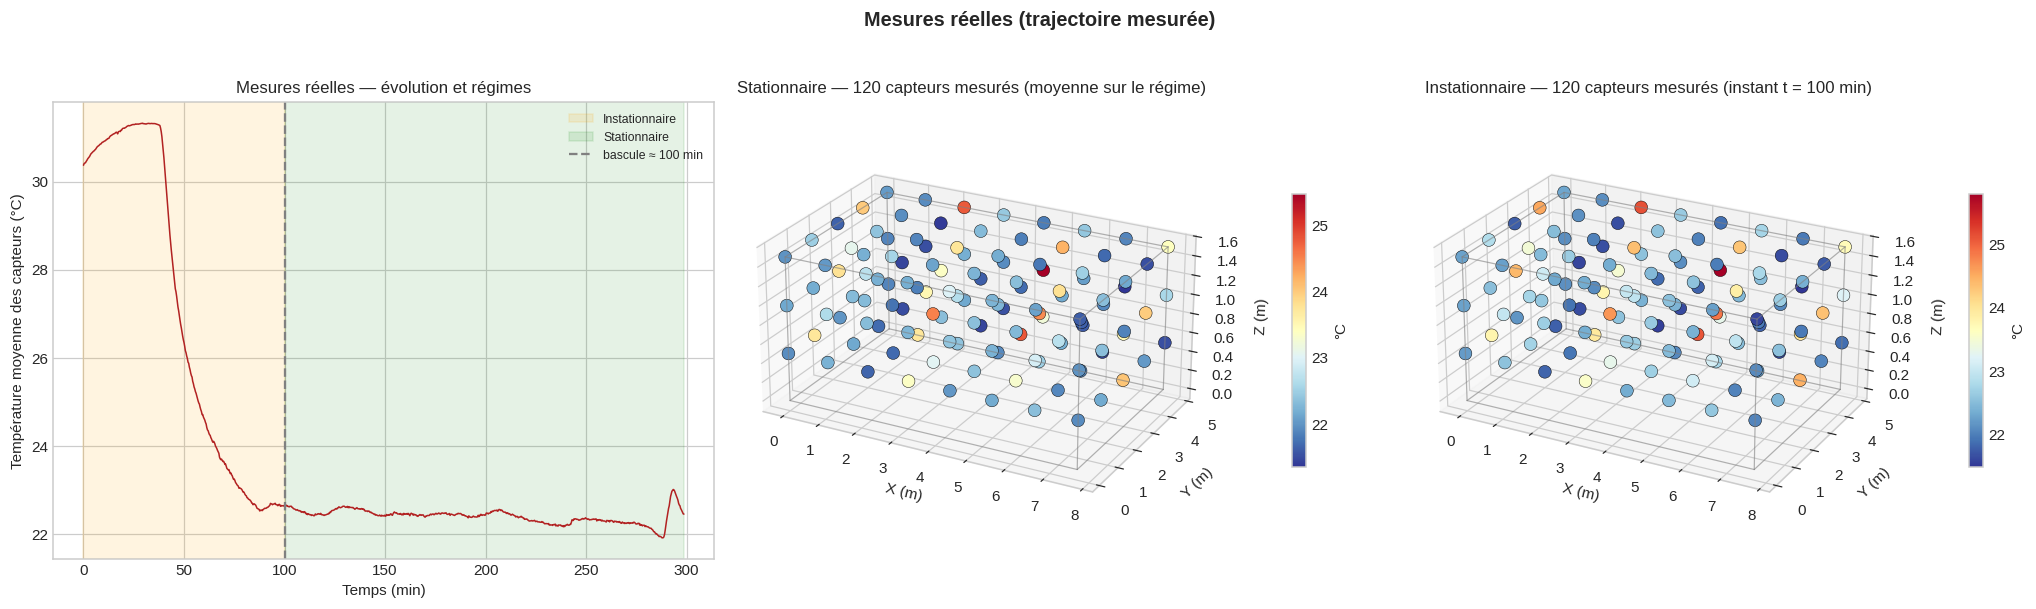

In [22]:
# === 10 — Visualisation des mesures réelles ===
CMAP = 'RdYlBu_r'
FRACTION_INSTANT_INSTATIONNAIRE = 1.0   # 0 = début, 1 = fin du régime instationnaire (instantané cartographié)

# Champ cartographié = trajectoire mesurée (Serpentine) : les 120 positions sont mesurées à chaque instant
#   stationnaire   -> moyenne temporelle par position sur tout le régime
#   instationnaire -> instantané (un pas de temps, les 120 capteurs) : le champ dérive, une moyenne le brouillerait
def champ_serpentine(phase):
    d = df_pred[(df_pred['trajectory_type'] == TRAJECTORY_TYPE_MESUREE) & (df_pred['phase'] == phase)]
    if len(d) == 0:
        return None, ''
    if phase == 'stationnaire':
        etiquette = 'moyenne sur le régime'
    else:
        t = np.sort(d['t_sec'].dropna().unique())
        t_snap = t[int(round(FRACTION_INSTANT_INSTATIONNAIRE * (len(t) - 1)))]
        d, etiquette = d[d['t_sec'] == t_snap], f'instant t = {t_snap / 60:.0f} min'
    return d.groupby(['x', 'y', 'z'])[['reel', 'predit']].mean().reset_index(), etiquette


CHAMPS, ETIQUETTES = {}, {}
for ph in REGIMES:
    c, e = champ_serpentine(ph)
    if c is not None:
        CHAMPS[ph], ETIQUETTES[ph] = c, e
REGIMES_CARTE = list(CHAMPS)
# Échelle de couleur commune réel / prédit pour chaque régime
VLIM = {ph: (min(c['reel'].min(), c['predit'].min()), max(c['reel'].max(), c['predit'].max()))
        for ph, c in CHAMPS.items()}
TITRES = {'stationnaire': 'Stationnaire', 'instationnaire': 'Instationnaire'}


def surface_lisse(d, colonne, n_x=180, n_y=110):
    """Champ continu sur TOUT le rectangle de la salle à partir d'une valeur par capteur (un niveau z).
    Spline bicubique interpolante sur la grille régulière 8 × 5 : définie partout, jamais de NaN
    (contrairement à un `griddata` limité à l'enveloppe convexe). Retourne (gx, gy, G) en mètres."""
    piv = d.pivot_table(index='x', columns='y', values=colonne, aggfunc='mean')
    xs = piv.index.values.astype(float) * ESPACEMENT_X
    ys = piv.columns.values.astype(float) * ESPACEMENT_Y
    Z = piv.values.astype(float)
    if np.isnan(Z).any():   # position manquante -> plus proche voisin, jamais de trou
        XX, YY = np.meshgrid(xs, ys, indexing='ij')
        ok = ~np.isnan(Z)
        Z = np.where(ok, Z, griddata((XX[ok], YY[ok]), Z[ok], (XX, YY), method='nearest'))
    spl = RectBivariateSpline(xs, ys, Z, kx=min(3, len(xs) - 1), ky=min(3, len(ys) - 1))
    gx, gy = np.linspace(0, LARGEUR_M, n_x), np.linspace(0, LONGUEUR_M, n_y)
    G = np.clip(spl(gx, gy).T, Z.min(), Z.max())     # (n_y, n_x), sans dépassement
    return gx, gy, G


def aretes_chambre():
    X0, X1, Y0, Y1, Z0, Z1 = 0, LARGEUR_M, 0, LONGUEUR_M, 0, HAUTEUR_M
    return [([X0, X1], [Y0, Y0], [Z0, Z0]), ([X0, X1], [Y1, Y1], [Z0, Z0]), ([X0, X0], [Y0, Y1], [Z0, Z0]),
            ([X1, X1], [Y0, Y1], [Z0, Z0]), ([X0, X1], [Y0, Y0], [Z1, Z1]), ([X0, X1], [Y1, Y1], [Z1, Z1]),
            ([X0, X0], [Y0, Y1], [Z1, Z1]), ([X1, X1], [Y0, Y1], [Z1, Z1]), ([X0, X0], [Y0, Y0], [Z0, Z1]),
            ([X1, X1], [Y0, Y0], [Z0, Z1]), ([X0, X0], [Y1, Y1], [Z0, Z1]), ([X1, X1], [Y1, Y1], [Z0, Z1])]


def habiller_axes_2d(ax):
    ax.set_xticks(np.arange(LARGEUR) * ESPACEMENT_X); ax.set_xticklabels([chr(ord('A') + i) for i in range(LARGEUR)])
    ax.set_yticks(np.arange(LONGUEUR) * ESPACEMENT_Y); ax.set_yticklabels(range(LONGUEUR))
    ax.set_xlabel('X (A–H)'); ax.set_ylabel('Y (0–4)')
    ax.grid(False)
    for s in SOURCES_CHAUD:   # emplacement des chauffages (config V3)
        ax.plot(s['x'] * ESPACEMENT_X, s['y'] * ESPACEMENT_Y, marker='^', color='red', mec='k', ms=7, zorder=6, clip_on=False)


# ---- Mesures réelles : évolution temporelle + champ mesuré en 3D ----
fig = plt.figure(figsize=(19, 5.6))
ax = fig.add_subplot(1, 3, 1)
t_min_arr = df['t_sec'].values / 60
ax.plot(t_min_arr, df['temperature_mean'], color='firebrick', lw=1)
if t_bascule is not None:
    ax.axvspan(0, t_bascule, color='orange', alpha=0.12, label='Instationnaire')
    ax.axvspan(t_bascule, t_min_arr.max(), color='green', alpha=0.10, label='Stationnaire')
    ax.axvline(t_bascule, color='gray', ls='--', label=f'bascule ≈ {t_bascule:.0f} min')
ax.set_xlabel('Temps (min)'); ax.set_ylabel('Température moyenne des capteurs (°C)')
ax.set_title('Mesures réelles — évolution et régimes'); ax.legend(fontsize=8)

for k, ph in enumerate(REGIMES_CARTE):
    ax = fig.add_subplot(1, 3, 2 + k, projection='3d')
    c = CHAMPS[ph].merge(positions_df[['x', 'y', 'z', 'x_m', 'y_m', 'z_m']], on=['x', 'y', 'z'])
    sc = ax.scatter(c['x_m'], c['y_m'], c['z_m'], c=c['reel'], cmap=CMAP, vmin=VLIM[ph][0], vmax=VLIM[ph][1],
                    s=70, edgecolor='k', linewidth=0.3, depthshade=False)
    for xs_, ys_, zs_ in aretes_chambre():
        ax.plot(xs_, ys_, zs_, color='gray', lw=0.8, alpha=0.6)
    ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)'); ax.set_zlabel('Z (m)')
    ax.set_box_aspect((LARGEUR_M, LONGUEUR_M, HAUTEUR_M * 2.5)); ax.view_init(elev=24, azim=-62)
    ax.set_title(f'{TITRES[ph]} — {N_CAPTEURS} capteurs mesurés ({ETIQUETTES[ph]})')
    fig.colorbar(sc, ax=ax, shrink=0.6, pad=0.14, label='°C')
plt.suptitle('Mesures réelles (trajectoire mesurée)', fontsize=13, fontweight='bold')
plt.tight_layout(rect=(0, 0, 1, 0.95)); plt.show()

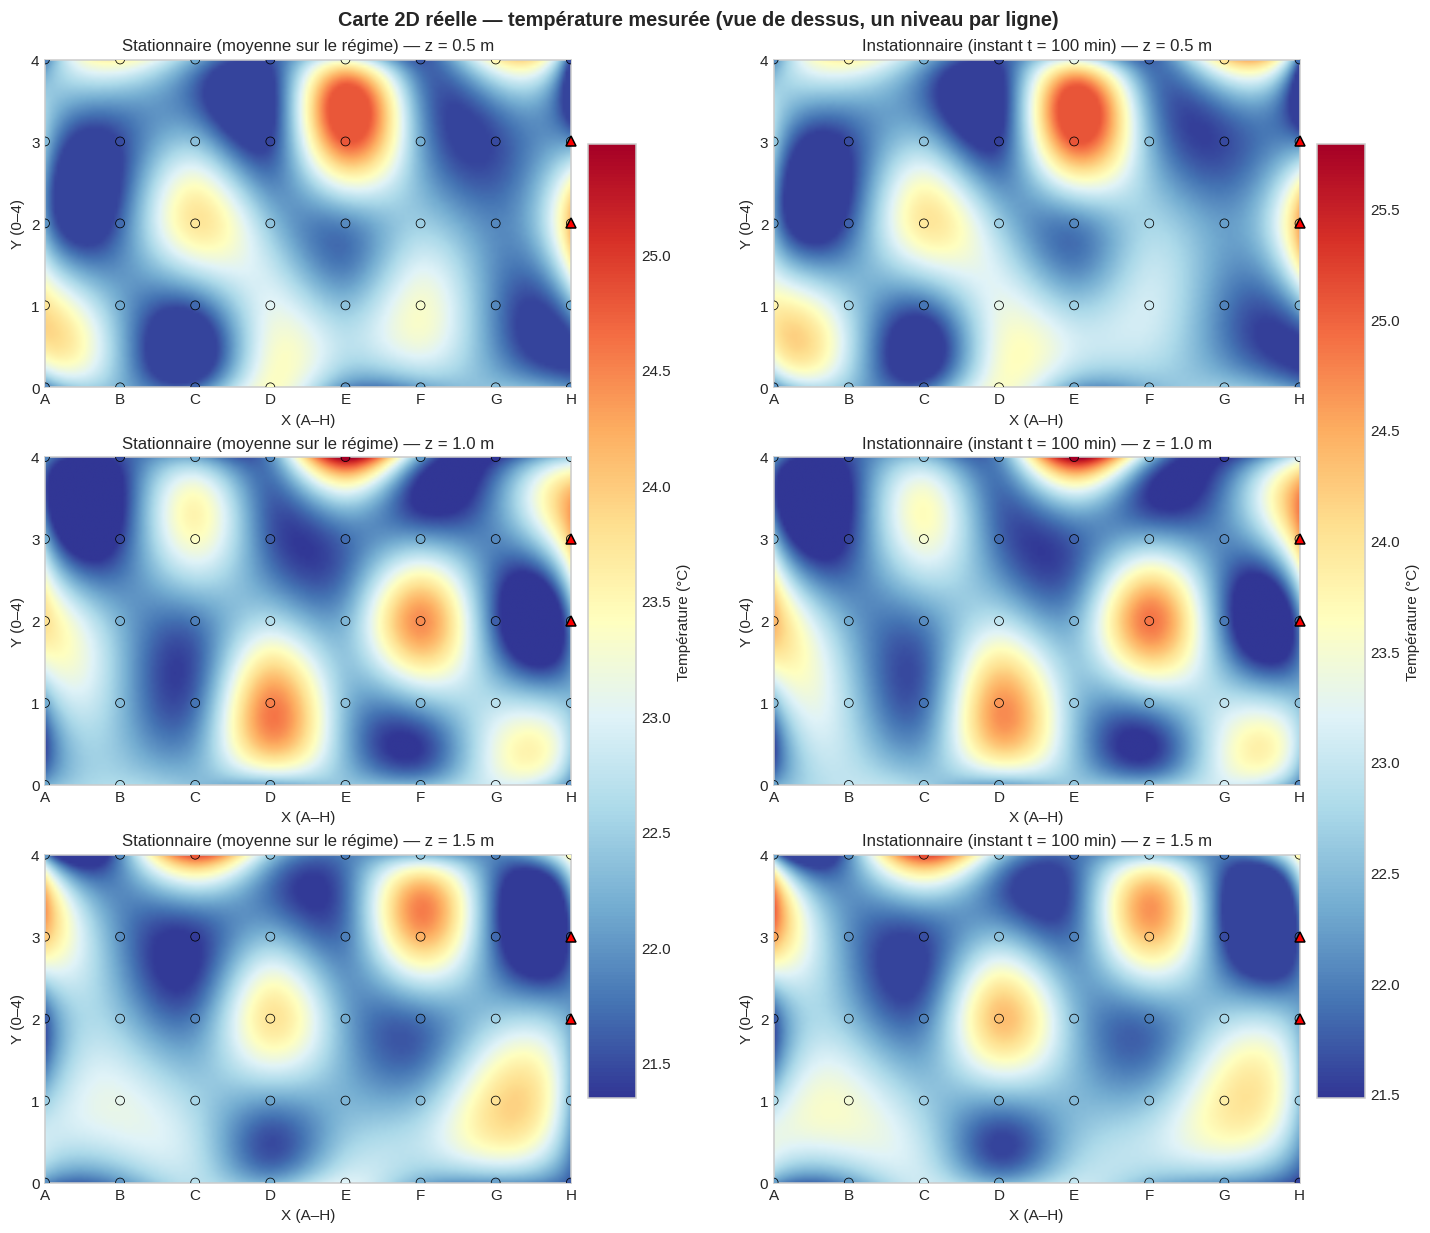

  pixels sans valeur : 0 (contrôle) — champ défini sur toute la salle 7.7 × 4.8 m


In [23]:
# === 11 — Carte 2D réelle (mesurée, interpolée entre capteurs) ===
def carte_2d(colonne, titre, points_couleur=True):
    n = len(REGIMES_CARTE)
    fig, axes = plt.subplots(HAUTEUR, n, figsize=(6.6 * n, 3.7 * HAUTEUR), squeeze=False, constrained_layout=True)
    for j, ph in enumerate(REGIMES_CARTE):
        vmin, vmax = VLIM[ph]
        for i, z in enumerate(sorted(CHAMPS[ph]['z'].unique())):
            ax = axes[i][j]
            d = CHAMPS[ph][CHAMPS[ph]['z'] == z]
            gx, gy, G = surface_lisse(d, colonne)
            assert np.isfinite(G).all(), 'zone blanche détectée'
            im = ax.imshow(G, origin='lower', extent=(0, LARGEUR_M, 0, LONGUEUR_M), cmap=CMAP, vmin=vmin, vmax=vmax,
                           aspect='equal', interpolation='bilinear')
            px, py = d['x'] * ESPACEMENT_X, d['y'] * ESPACEMENT_Y
            if points_couleur:
                ax.scatter(px, py, c=d[colonne], cmap=CMAP, vmin=vmin, vmax=vmax, s=34, edgecolor='k', linewidth=0.5, zorder=5)
            else:
                ax.scatter(px, py, c='k', s=6, zorder=5)
            habiller_axes_2d(ax)
            ax.set_title(f'{TITRES[ph]} ({ETIQUETTES[ph]}) — z = {ALTITUDES_Z[int(z)]:.1f} m')
        fig.colorbar(im, ax=axes[:, j], shrink=0.85, pad=0.02, label='Température (°C)')
    fig.suptitle(titre, fontsize=13, fontweight='bold')
    plt.show()
    print(f'  pixels sans valeur : 0 (contrôle) — champ défini sur toute la salle {LARGEUR_M:.1f} × {LONGUEUR_M:.1f} m')


carte_2d('reel', 'Carte 2D réelle — température mesurée (vue de dessus, un niveau par ligne)')

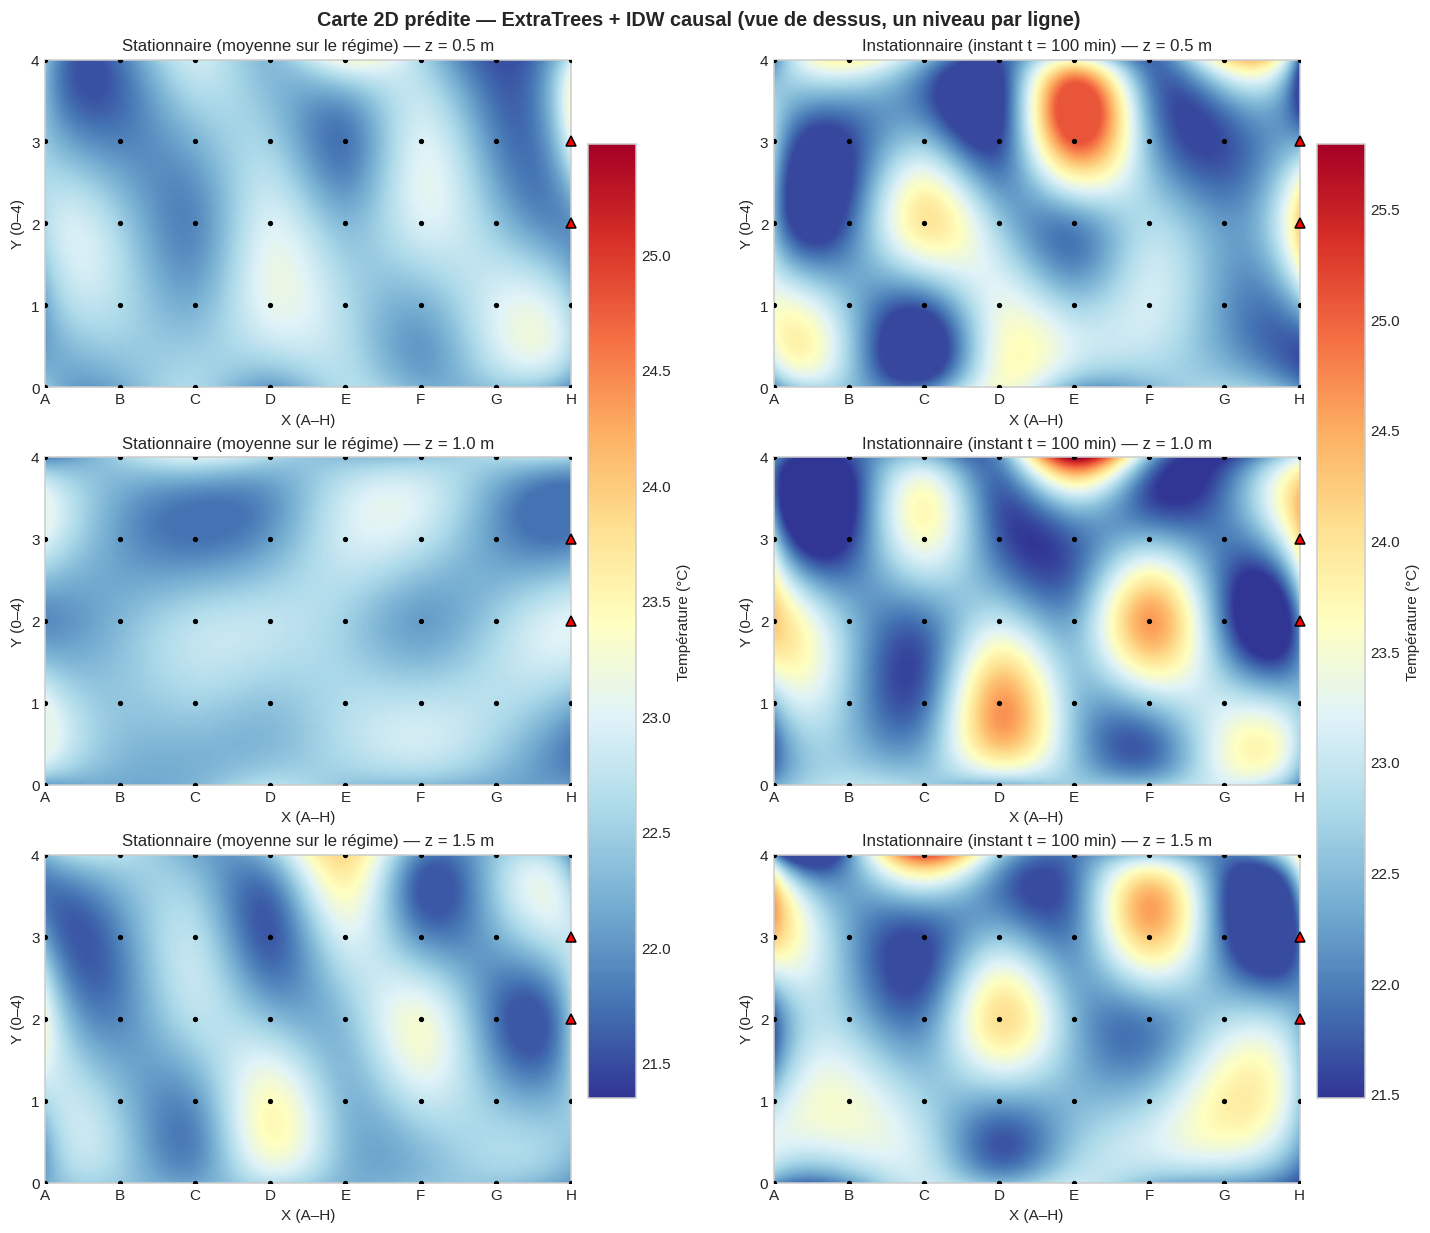

  pixels sans valeur : 0 (contrôle) — champ défini sur toute la salle 7.7 × 4.8 m


In [24]:
# === 12 — Carte 2D prédite, entièrement remplie (aucune zone blanche) ===
# Modèle final de chaque régime (ExtraTrees + IDW causal) évalué aux 120 positions, puis spline continue
# sur toute la salle : chaque pixel a une valeur (les points noirs = positions où le modèle est évalué).
carte_2d('predit', 'Carte 2D prédite — ExtraTrees + IDW causal (vue de dessus, un niveau par ligne)', points_couleur=False)

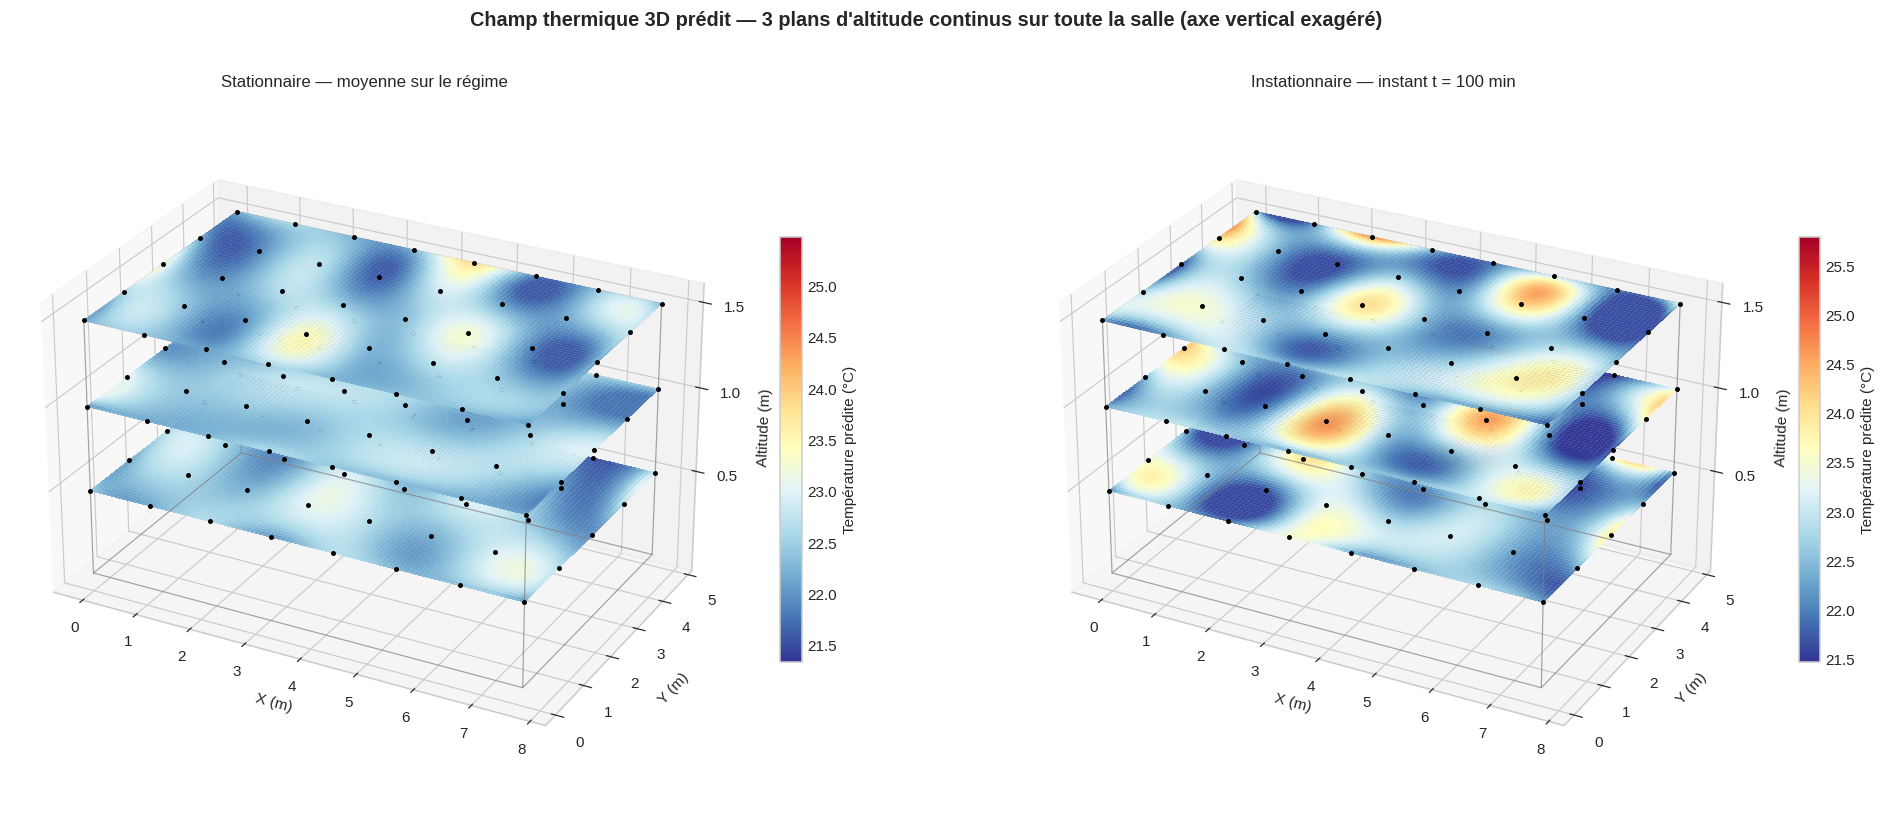

In [25]:
# === 13 — Visualisation 3D du champ thermique complet (prédit) ===
def dessiner_champ_3d(ax, champ, colonne, norm):
    """Un plan continu par altitude de capteur (0.5 / 1.0 / 1.5 m) : le champ prédit couvre toute la salle."""
    for z in sorted(champ['z'].unique()):
        d = champ[champ['z'] == z]
        gx, gy, G = surface_lisse(d, colonne, n_x=100, n_y=62)
        X, Y = np.meshgrid(gx, gy)
        ax.plot_surface(X, Y, np.full_like(X, ALTITUDES_Z[int(z)]), facecolors=plt.get_cmap(CMAP)(norm(G)),
                        rstride=1, cstride=1, shade=False, linewidth=0, antialiased=False, alpha=0.88)
        ax.scatter(d['x'] * ESPACEMENT_X, d['y'] * ESPACEMENT_Y, np.full(len(d), ALTITUDES_Z[int(z)]),
                   c='k', s=5, depthshade=False)
    for xs_, ys_, zs_ in aretes_chambre():
        ax.plot(xs_, ys_, zs_, color='gray', lw=0.8, alpha=0.7)
    ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)'); ax.set_zlabel('Altitude (m)')
    ax.set_zticks(ALTITUDES_Z)
    ax.set_box_aspect((LARGEUR_M, LONGUEUR_M, HAUTEUR_M * 3)); ax.view_init(elev=27, azim=-62)


n = len(REGIMES_CARTE)
fig = plt.figure(figsize=(9.5 * n, 7.5))
for j, ph in enumerate(REGIMES_CARTE):
    ax = fig.add_subplot(1, n, j + 1, projection='3d')
    norm = colors.Normalize(*VLIM[ph])
    dessiner_champ_3d(ax, CHAMPS[ph], 'predit', norm)
    ax.set_title(f'{TITRES[ph]} — {ETIQUETTES[ph]}')
    fig.colorbar(cm.ScalarMappable(norm=norm, cmap=CMAP), ax=ax, shrink=0.6, pad=0.06, label='Température prédite (°C)')
plt.suptitle('Champ thermique 3D prédit — 3 plans d\'altitude continus sur toute la salle '
             '(axe vertical exagéré)', fontsize=13, fontweight='bold')
plt.tight_layout(rect=(0, 0, 1, 0.94)); plt.show()

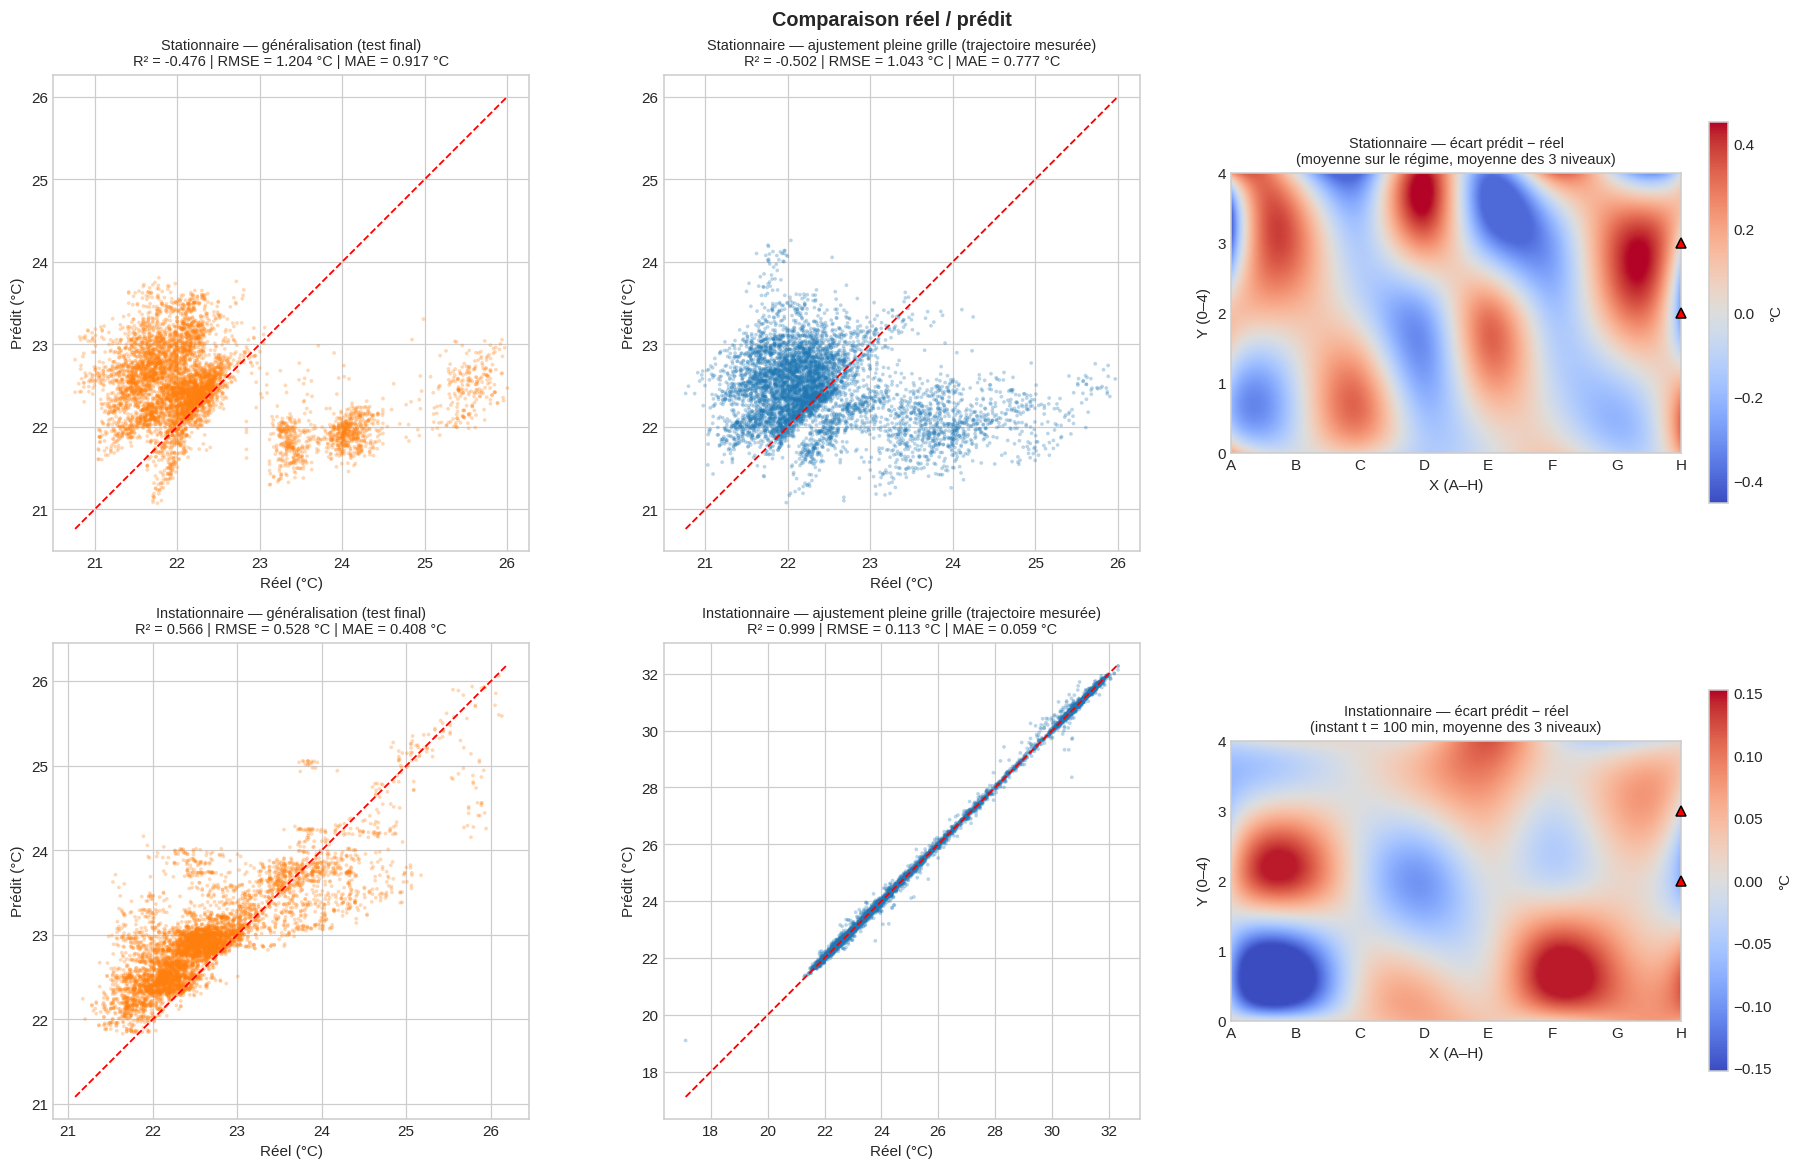

In [26]:
# === 14 — Comparaison réel / prédit ===
def metriques(y, p):
    return dict(RMSE=float(np.sqrt(mean_squared_error(y, p))), MAE=float(mean_absolute_error(y, p)),
                R2=float(r2_score(y, p)))


def parite(ax, y, p, titre, couleur, n_max=6000):
    rng = np.random.RandomState(0)
    idx = rng.choice(len(y), size=min(n_max, len(y)), replace=False)
    ax.scatter(y[idx], p[idx], s=6, alpha=0.3, color=couleur, edgecolor='none')
    lo, hi = min(y.min(), p.min()), max(y.max(), p.max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1.2)
    m = metriques(y, p)
    ax.set_title(f'{titre}\nR² = {m["R2"]:.3f} | RMSE = {m["RMSE"]:.3f} °C | MAE = {m["MAE"]:.3f} °C', fontsize=9.5)
    ax.set_xlabel('Réel (°C)'); ax.set_ylabel('Prédit (°C)'); ax.set_aspect('equal', adjustable='box')


n = len(REGIMES_CARTE)
fig, axes = plt.subplots(n, 3, figsize=(17, 5.4 * n), squeeze=False)
for i, ph in enumerate(REGIMES_CARTE):
    h = HOLDOUT[ph]
    parite(axes[i][0], h['reel'], h['predit'], f'{TITRES[ph]} — généralisation (test final)', 'tab:orange')

    d = df_pred[(df_pred['phase'] == ph) & (df_pred['trajectory_type'] == TRAJECTORY_TYPE_MESUREE)]
    parite(axes[i][1], d['reel'].values, d['predit'].values,
           f'{TITRES[ph]} — ajustement pleine grille (trajectoire mesurée)', 'tab:blue')

    # Écart prédit - réel sur la salle (moyenne sur les 3 altitudes) : carte continue, échelle symétrique
    e = CHAMPS[ph].assign(ecart=lambda t: t['predit'] - t['reel']).groupby(['x', 'y'], as_index=False)['ecart'].mean()
    gx, gy, G = surface_lisse(e, 'ecart')
    lim = max(abs(G).max(), 1e-6)
    ax = axes[i][2]
    im = ax.imshow(G, origin='lower', extent=(0, LARGEUR_M, 0, LONGUEUR_M), cmap='coolwarm', vmin=-lim, vmax=lim,
                   aspect='equal', interpolation='bilinear')
    habiller_axes_2d(ax)
    ax.set_title(f'{TITRES[ph]} — écart prédit − réel\n({ETIQUETTES[ph]}, moyenne des 3 niveaux)', fontsize=9.5)
    fig.colorbar(im, ax=ax, shrink=0.8, label='°C')
plt.suptitle('Comparaison réel / prédit', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [27]:
# === 15 — Métriques finales : RMSE, MAE, R² ===
lignes = []
for ph in REGIMES_CARTE:
    h = HOLDOUT[ph]
    lignes.append({'Régime': ph, 'Évaluation': 'Généralisation — test final (hors échantillon)', 'Modèle': 'IDW causal + ExtraTrees',
                   'n': len(h['reel']), **metriques(h['reel'], h['predit'])})
    lignes.append({'Régime': ph, 'Évaluation': 'Généralisation — test final (hors échantillon)', 'Modèle': 'IDW causal seul (référence)',
                   'n': len(h['reel']), **metriques(h['reel'], h['idw'])})
    d = df_pred[df_pred['phase'] == ph]
    lignes.append({'Régime': ph, 'Évaluation': 'Ajustement pleine grille (tous les points, non généralisation)', 'Modèle': 'IDW causal + ExtraTrees',
                   'n': len(d), **metriques(d['reel'].values, d['predit'].values)})
metriques_finales = pd.DataFrame(lignes).set_index(['Régime', 'Évaluation', 'Modèle'])
metriques_finales = metriques_finales.rename(columns={'RMSE': 'RMSE (°C)', 'MAE': 'MAE (°C)'})
display(metriques_finales.round(4))
print('Lecture : seules les lignes « généralisation » mesurent la qualité sur des positions (stationnaire) ou des instants '
      '(instationnaire) jamais vus ; « ajustement » = modèle évalué sur les points qui ont servi à l\'entraîner.')

n  \
Régime         Évaluation                                         Modèle                                
stationnaire   Généralisation — test final (hors échantillon)     IDW causal + ExtraTrees       41193   
                                                                  IDW causal seul (référence)   41193   
               Ajustement pleine grille (tous les points, non ... IDW causal + ExtraTrees      204174   
instationnaire Généralisation — test final (hors échantillon)     IDW causal + ExtraTrees       20384   
                                                                  IDW causal seul (référence)   20384   
               Ajustement pleine grille (tous les points, non ... IDW causal + ExtraTrees      101916   

                                                                                               RMSE (°C)  \
Régime         Évaluation                                         Modèle                                   
stationnaire   Généralisation — test final (hors échantillon)     IDW causal + ExtraTrees         1.2041   
                                                                  IDW causal seul (référence)     1.2041   
               Ajustement pleine grille (tous les points, non ... IDW causal + ExtraTrees         1.0539   
instationnaire Généralisation — test final (hors échantillon)     IDW causal + ExtraTrees         0.5282   
                                                                  IDW causal seul (référence)     0.9848   
               Ajustement pleine grille (tous les points, non ... IDW causal + ExtraTrees         0.1063   

                                                                                               MAE (°C)  \
Régime         Évaluation                                         Modèle                                  
stationnaire   Généralisation — test final (hors échantillon)     IDW causal + ExtraTrees        0.9172   
                                                                  IDW causal seul (référence)    0.9172   
               Ajustement pleine grille (tous les points, non ... IDW causal + ExtraTrees        0.7901   
instationnaire Généralisation — test final (hors échantillon)     IDW causal + ExtraTrees        0.4078   
                                                                  IDW causal seul (référence)    0.7330   
               Ajustement pleine grille (tous les points, non ... IDW causal + ExtraTrees        0.0585   

                                                                                                   R2  
Régime         Évaluation                                         Modèle                               
stationnaire   Généralisation — test final (hors échantillon)     IDW causal + ExtraTrees     -0.4755  
                                                                  IDW causal seul (référence) -0.4755  
               Ajustement pleine grille (tous les points, non ... IDW causal + ExtraTrees     -0.5095  
instationnaire Généralisation — test final (hors échantillon)     IDW causal + ExtraTrees      0.5665  
                                                                  IDW causal seul (référence) -0.5072  
               Ajustement pleine grille (tous les points, non ... IDW causal + ExtraTrees      0.9992

Lecture : seules les lignes « généralisation » mesurent la qualité sur des positions (stationnaire) ou des instants (instationnaire) jamais vus ; « ajustement » = modèle évalué sur les points qui ont servi à l'entraîner.


## 16 — Limites

- **Généralisation ≠ ajustement.** Les cartes utilisent les modèles finaux entraînés sur tous les points : elles reproduisent bien les mesures par construction. La qualité sur des données jamais vues est celle du test final (table des métriques) ; en stationnaire il ne compte que 24 positions tenues à l'écart, donc le R² y est bruité et peut être faible, voire négatif.
- **Les cartes sont des interpolations lisses.** Le modèle est évalué aux 120 positions de capteurs ; entre capteurs, le champ est une spline continue de ces valeurs, pas une mesure ni une sortie du modèle. Un phénomène local plus fin que l'espacement des capteurs (1,1 m × 1,2 m × 0,5 m) n'est pas visible.
- **Régime instationnaire cartographié par instantané.** Le champ dérive dans le temps ; la carte montre un pas de temps (`FRACTION_INSTANT_INSTATIONNAIRE`), pas l'évolution complète.
- **`idw_causal` est calculé sur toutes les positions avant les splits** (protocole V3 conservé tel quel) : des valeurs de positions voisines du test peuvent entrer dans les features du train.
- **Trajectoires simulées.** Périmètre, Zigzag, Aléatoire et FPS sont des sous-ensembles de la même mesure, pas des campagnes indépendantes.
- **Une seule campagne de mesure**, un seul chauffage (est, deux sources) ; `direction_encode` est constante sur ce fichier, donc sans information.
- **Données très denses** : les 120 capteurs sont lus à chaque pas de temps, ce qui suggère un rééchantillonnage en amont ; à vérifier auprès du protocole de mesure.
- **Géométrie et sources CVC statiques** : toute source non déclarée dans `SOURCES_CHAUD` / `SOURCES_FROID` n'est pas prise en compte.

In [28]:
# === 17 — Conclusion (chiffres calculés ci-dessus) ===
def _ligne(ph, evaluation, modele='IDW causal + ExtraTrees'):
    r = metriques_finales.loc[(ph, evaluation, modele)]
    return f"R² = {r['R2']:.3f}, RMSE = {r['RMSE (°C)']:.3f} °C, MAE = {r['MAE (°C)']:.3f} °C"


EV_GEN = 'Généralisation — test final (hors échantillon)'
EV_FIT = 'Ajustement pleine grille (tous les points, non généralisation)'
texte = ['### Modèles retenus\n']
for ph in REGIMES_CARTE:
    p = MODELES_FINAUX[ph]['modele']
    gain = (metriques_finales.loc[(ph, EV_GEN, 'IDW causal + ExtraTrees'), 'RMSE (°C)']
            - metriques_finales.loc[(ph, EV_GEN, 'IDW causal seul (référence)'), 'RMSE (°C)'])
    r2 = metriques_finales.loc[(ph, EV_GEN, 'IDW causal + ExtraTrees'), 'R2']
    texte.append(f"- **{TITRES[ph]}** : ExtraTrees sur le résidu de l'IDW causal "
                 f"(`n_estimators={p.n_estimators}`, `max_depth={p.max_depth}`, `min_samples_leaf={p.min_samples_leaf}`).  \n"
                 f"  Généralisation (test final) : {_ligne(ph, EV_GEN)} — "
                 f"{'meilleur' if gain < 0 else 'moins bon'} que l'IDW causal seul en RMSE ({gain:+.3f} °C).  \n"
                 f"  Ajustement pleine grille (cartes) : {_ligne(ph, EV_FIT)}."
                 + ('  \n  ⚠️ R² de généralisation négatif : sur ces positions/instants, le modèle ne fait pas mieux que la moyenne '
                    'du test — les cartes reflètent surtout l\'ajustement aux mesures.' if r2 < 0 else ''))
texte.append('\n### Ce que montrent les cartes\n')
texte.append('Les cartes 2D (réelle, prédite) et la vue 3D couvrent toute la salle sans zone blanche : le modèle final est évalué '
             'aux 120 positions puis relié par une spline continue. Les écarts prédit − réel sont visibles sur la figure de comparaison.\n')
texte.append('Les limites (généralisation vs ajustement, interpolation entre capteurs, instantané instationnaire) sont détaillées en section 16.')
display(Markdown('\n'.join(texte)))

### Modèles retenus

- **Stationnaire** : ExtraTrees sur le résidu de l'IDW causal (`n_estimators=500`, `max_depth=10`, `min_samples_leaf=4`).  
  Généralisation (test final) : R² = -0.476, RMSE = 1.204 °C, MAE = 0.917 °C — moins bon que l'IDW causal seul en RMSE (+0.000 °C).  
  Ajustement pleine grille (cartes) : R² = -0.509, RMSE = 1.054 °C, MAE = 0.790 °C.  
  ⚠️ R² de généralisation négatif : sur ces positions/instants, le modèle ne fait pas mieux que la moyenne du test — les cartes reflètent surtout l'ajustement aux mesures.
- **Instationnaire** : ExtraTrees sur le résidu de l'IDW causal (`n_estimators=300`, `max_depth=20`, `min_samples_leaf=2`).  
  Généralisation (test final) : R² = 0.566, RMSE = 0.528 °C, MAE = 0.408 °C — meilleur que l'IDW causal seul en RMSE (-0.457 °C).  
  Ajustement pleine grille (cartes) : R² = 0.999, RMSE = 0.106 °C, MAE = 0.058 °C.

### Ce que montrent les cartes

Les cartes 2D (réelle, prédite) et la vue 3D couvrent toute la salle sans zone blanche : le modèle final est évalué aux 120 positions puis relié par une spline continue. Les écarts prédit − réel sont visibles sur la figure de comparaison.

Les limites (généralisation vs ajustement, interpolation entre capteurs, instantané instationnaire) sont détaillées en section 16.